In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import uproot
import psutil, os, gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, Dataset, DataLoader, TensorDataset
import csv
 
# ── project paths ───────────────────────────────────────────────────────────
def find_project_root(marker="Data", start=None):
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")
 
PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)
 
def mem():
    p = psutil.Process(os.getpid())
    print(f"  mem: {p.memory_info().rss / 1e9:.2f} GB")

print(os.getcwd())

project root: /home/olivermcroy/AppliedML2026/ML_FinalProject
/home/olivermcroy/AppliedML2026/ML_FinalProject


In [ ]:
# ── run selection ───────────────────────────────────────────────────────────
labels_df = pd.read_csv(LABELS_CSV)
runs_df = labels_df.query(
    "run == 445 or run == 446 or run == 448 or run == 450 or "
    "run == 451 or run == 452 or run == 458 or run == 459"
).copy()
print("runs to load:")
print(runs_df.to_string(index=False))


# ── configuration ───────────────────────────────────────────────────────────
LEAVE_OUT_ENERGY     = 150
MAX_EVENTS_PER_RUN   = 15000
MAPPING_PATH = "/home/olivermcroy/AppliedML2026/ML_FinalProject/channelmapping.channelmapping"
print(f"\nHolding out {LEAVE_OUT_ENERGY} GeV from training")
print(f"Loading at most {MAX_EVENTS_PER_RUN} events per run")




# ── helpers ─────────────────────────────────────────────────────────────────
def find_root_file(run, data_dir=DATA_DIR):
    candidates = (list(data_dir.glob(f"Run{run}*.root"))
                + list(data_dir.glob(f"Run{run:04d}*.root")))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

def decode_tot_inplace(arr: np.ndarray) -> None:
    """
    H2GCROC ToT convention — applied IN-PLACE (no copy).
    Values > 511: mask to 10 bits, shift left by 3.
    arr must be a writable integer array.
    """
    mask = arr > 511
    arr[mask] = (arr[mask].astype(np.int32) & 0b0111111111) << 3


def subtract_pedestal_inplace(arr: np.ndarray) -> None:
    """
    Pedestal subtraction — applied IN-PLACE.
 
    arr shape: (n_events, n_boards, 38, 64)
        axis -2 (size 38) = time-sample index
        axis -1 (size 64) = channel/slot index
 
    Pedestal = mean of samples 1, 2, 3 (sample 0 is always a sync zero).
    One pedestal value per (event, board, channel) → shape (n, boards, 1, 64).
    Negative values after subtraction are clipped to 0.
 
    Works on int16 throughout — no float intermediate array is created.
    The temporary pedestal array costs only  n_events * n_boards * 64 * 2 bytes
    (≈ 57 MB for 56 000 events with 4 boards), then is immediately freed.
    """
    # Round-mean over 3 samples -> still fits in int16 (max ~341 per channel)
    ped = arr[:, :, 1:4, :].sum(axis=2, keepdims=True)   # int32 to avoid overflow
    ped = ((ped + 1) // 3).astype(np.int16)               # integer round-divide
    arr -= ped                                             # in-place, stays int16
    del ped
    np.clip(arr, 0, None, out=arr)                        # clip negatives in-place


mapping_df = pd.read_csv(MAPPING_PATH, sep="\t")

# Detector geometry mapping


CONNECTED_CHANNELS = set(
    list(range(0, 8)) +
    list(range(9, 17)) +
    list(range(18, 26)) +
    list(range(27, 35))
)

USED_HALVES_BY_VLDB = {
    0: {0, 1},
    1: {0, 1, 2, 3},
}

N_SAMPLES = 16
SLOTS_PER_HALF = 38
VALUES_PER_VLDB = 4 * SLOTS_PER_HALF   # 152

BOARD_ROWS, BOARD_COLS = 3, 2
BOARD_H, BOARD_W = 4, 8



def normalize_half(asic, half):
    if half in (2, 3):
        return half
    if half in (0, 1) and asic in (0, 1):
        return 2 * asic + half
    raise ValueError(f"Bad ASIC/HALF combination: ASIC={asic}, HALF={half}")


def channel_to_raw_index(half_global, ch):
    if ch <= 17:
        slot = ch + 1
    else:
        slot = ch + 2

    return half_global * SLOTS_PER_HALF + slot


def flip_selected_boards(row, col):

    board_row = row // BOARD_H
    board_col = col // BOARD_W

    if (board_row, board_col) not in {(0,1), (1,1), (2,0)}:
        return row, col

    r0 = board_row * BOARD_H
    c0 = board_col * BOARD_W

    local_r = row - r0
    local_c = col - c0

    return r0 + (BOARD_H - 1 - local_r), col


def load_detector_mapping(mapping_file):

    mapping = []

    max_row = -1
    max_col = -1

    with open(mapping_file, "r") as f:

        reader = csv.DictReader(f, delimiter="\t")

        for line in reader:

            row  = int(line["ROW"])
            col  = int(line["COL"])
            vldb = int(line["VLDB"])
            asic = int(line["ASIC"])
            half = int(line["HALF"])
            ch   = int(line["CHANNEL"])

            max_row = max(max_row, row)
            max_col = max(max_col, col)

            if ch not in CONNECTED_CHANNELS:
                continue

            half_global = normalize_half(asic, half)

            if half_global not in USED_HALVES_BY_VLDB.get(vldb, {0,1,2,3}):
                continue

            raw_index = channel_to_raw_index(
                half_global,
                ch
            )

            row, col = flip_selected_boards(
                row,
                col
            )

            mapping.append(
                (vldb, raw_index, row, col)
            )

    n_rows = max_row + 1
    n_cols = max_col + 1

    return mapping, n_rows, n_cols


MAPPING, DET_ROWS, DET_COLS = load_detector_mapping(
    MAPPING_PATH
)

print(
    f"Detector geometry: "
    f"{DET_ROWS} x {DET_COLS}"
)
print(mapping_df)


def event_to_detector_image(
    fpga0,
    fpga1,
    mapping,
    n_rows,
    n_cols
):
    """
    fpga0 shape:
        (16,152)

    fpga1 shape:
        (16,152)

    returns:
        (16,12,16)
    """

    img = np.zeros(
        (
            N_SAMPLES,
            n_rows,
            n_cols
        ),
        dtype=np.float32
    )

    for vldb, raw_index, row, col in mapping:

        if vldb == 0:
            img[:, row, col] = fpga0[:, raw_index]
        else:
            img[:, row, col] = fpga1[:, raw_index]

    return img




runs to load:
 run  energy_GeV particle  bias_V
 445         150        h       0
 446         200        h       0
 448         300        h       0
 450         100        h       0
 451          80        h       0
 452          60        h       0
 458         250        h       0
 459         350        h       0

Holding out 150 GeV from training
Loading at most 15000 events per run
Detector geometry: 12 x 16
     ROW  COL  VLDB  ASIC  HALF  CHANNEL
0      0    0     1     1     0        2
1      0    1     1     1     0        6
2      0    2     1     1     0       12
3      0    3     1     1     0       14
4      0    4     1     1     0       21
..   ...  ...   ...   ...   ...      ...
187   11   11     0     0     1       21
188   11   12     0     0     1       14
189   11   13     0     0     1       12
190   11   14     0     0     1        6
191   11   15     0     0     1        2

[192 rows x 6 columns]



Loading TRAIN set (7 runs, excluding 150 GeV)…
  Run 446:  15000 events (h, 200 GeV)
  mem: 1.97 GB
  Run 448:  15000 events (h, 300 GeV)
  mem: 2.37 GB
  Run 450:  15000 events (h, 100 GeV)
  mem: 2.74 GB
  Run 451:  15000 events (h, 80 GeV)
  mem: 3.12 GB
  Run 452:  15000 events (h, 60 GeV)
  mem: 3.50 GB
  Run 458:  15000 events (h, 250 GeV)
  mem: 3.91 GB
  Run 459:  15000 events (h, 350 GeV)
  mem: 4.28 GB

Total events: 105000
Detector tensor shape: (105000, 2, 12, 16, 16)

Loading VAL set (8 runs, all energies)…
  Run 445:  15000 events (h, 150 GeV)
  mem: 4.67 GB
  Run 446:  15000 events (h, 200 GeV)
  mem: 5.13 GB
  Run 448:  15000 events (h, 300 GeV)
  mem: 5.50 GB
  Run 450:  15000 events (h, 100 GeV)
  mem: 5.80 GB
  Run 451:  15000 events (h, 80 GeV)
  mem: 6.17 GB
  Run 452:  15000 events (h, 60 GeV)
  mem: 6.54 GB
  Run 458:  15000 events (h, 250 GeV)
  mem: 6.89 GB
  Run 459:  15000 events (h, 350 GeV)
  mem: 7.27 GB

Total events: 120000
Detector tensor shape: (12000

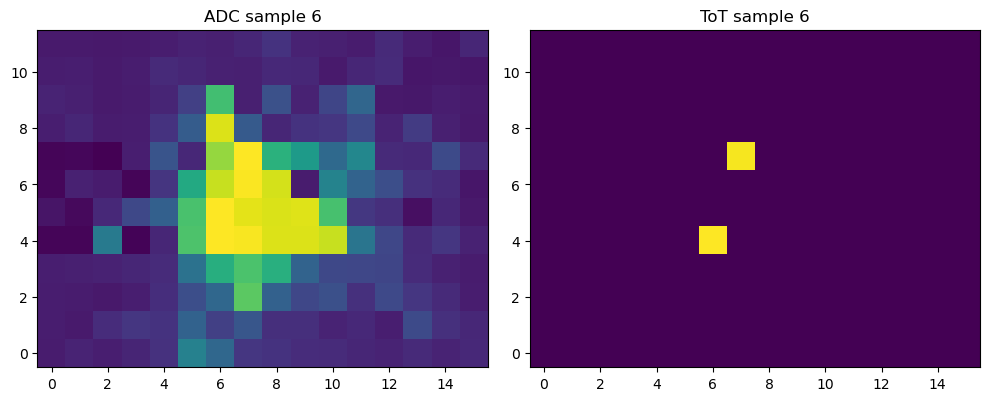

In [ ]:
PEDESTAL_START = 0
PEDESTAL_STOP = 3
N_LOWEST = 3

def subtract_pedestal(event_data):
    early = event_data[PEDESTAL_START:PEDESTAL_STOP, :]
    lowest = np.partition(early, N_LOWEST - 1, axis=0)[:N_LOWEST, :]
    pedestal = np.mean(lowest, axis=0, keepdims=True)
    return event_data - pedestal


# main loading function
def load_runs(
    runs_df: pd.DataFrame,
    max_events_per_run: int = MAX_EVENTS_PER_RUN
):
    """
    Returns detector-image tensors.

    X shape:
        (N, 2, 12, 16, 16)

    Dimensions:
        channel 0 = ADC
        channel 1 = ToT

        detector rows = 12
        detector cols = 16

        time samples = 16
    """

    X_chunks = []

    run_ids = []
    parts = []
    biases = []
    energies = []

    for _, row in runs_df.iterrows():

        f = find_root_file(int(row["run"]))
        t = uproot.open(f)["data_tree"]

        n = min(
            t.num_entries,
            max_events_per_run
        )
       
        adc0 = (t["val0_list_0"].array(library="np", entry_stop=n).reshape(n, N_SAMPLES, VALUES_PER_VLDB).astype(np.int16))

        adc1 = (t["val0_list_1"].array(library="np", entry_stop=n).reshape(n, N_SAMPLES, VALUES_PER_VLDB).astype(np.int16))

        tot0 = (t["val1_list_0"].array(library="np", entry_stop=n).reshape(n, N_SAMPLES, VALUES_PER_VLDB).astype(np.int16))

        tot1 = (t["val1_list_1"].array(library="np", entry_stop=n).reshape(n, N_SAMPLES, VALUES_PER_VLDB).astype(np.int16))


        adc_images = np.empty(
            (
                n,
                N_SAMPLES,
                DET_ROWS,
                DET_COLS
            ),
            dtype=np.float32
        )

        tot_images = np.empty_like(adc_images)


        for i_evt in range(n):

            adc_evt0 = subtract_pedestal(adc0[i_evt].astype(np.float32))

            adc_evt1 = subtract_pedestal(adc1[i_evt].astype(np.float32))

            tot_evt0 = subtract_pedestal(tot0[i_evt].astype(np.float32))

            tot_evt1 = subtract_pedestal(tot1[i_evt].astype(np.float32))

            adc_images[i_evt] = event_to_detector_image(
                adc_evt0,
                adc_evt1,
                MAPPING,
                DET_ROWS,
                DET_COLS
            )

            tot_images[i_evt] = event_to_detector_image(
                tot_evt0,
                tot_evt1,
                MAPPING,
                DET_ROWS,
                DET_COLS
            )

        # stack ADC + ToT

        X_run = np.stack([adc_images, tot_images], axis=1)

        # Current:
        # (n, 2, 16, 12, 16)

        X_run = np.transpose(
            X_run,
            (
                0,  # events
                1,  # adc/tot
                3,  # rows
                4,  # cols
                2   # time
            )
        )

        # Final:
        # (n, 2, 12, 16, 16)

        X_chunks.append(X_run)

        run_ids.append(np.full(n, int(row["run"]), dtype=np.int32))

        parts.append(np.full(n, row["particle"], dtype="U1"))

        biases.append(np.full(n, int(row["bias_V"]), dtype=np.int32))

        energies.append(np.full(n, int(row["energy_GeV"])))

        print(
            f"  Run {row.run:03d}: "
            f"{n:6d} events "
            f"({row.particle}, "
            f"{row.energy_GeV} GeV)"
        )

        mem()

        del adc0
        del adc1
        del tot0
        del tot1
        del adc_images
        del tot_images

        gc.collect()


    # Combine runs

    X = np.concatenate(
        X_chunks,
        axis=0
    )

    del X_chunks
    gc.collect()

    energy = np.concatenate(energies).astype(np.float32)

    run_id = np.concatenate(run_ids)

    particle = np.concatenate(parts)

    bias_v = np.concatenate(biases)

    del energies
    del run_ids
    del parts
    del biases

    gc.collect()

    print(
        f"\nTotal events: {X.shape[0]}"
    )

    print(
        f"Detector tensor shape: "
        f"{X.shape}"
    )

    y = np.log1p(
        energy
    )

    return (X, y, energy, run_id, particle, bias_v) 
 

# split and load
train_runs_df = runs_df[runs_df.energy_GeV != LEAVE_OUT_ENERGY].copy()
val_runs_df   = runs_df.copy()

print(f"\nLoading TRAIN set ({len(train_runs_df)} runs, excluding {LEAVE_OUT_ENERGY} GeV)…")
X_train, y_train, *_ = load_runs(train_runs_df, MAX_EVENTS_PER_RUN)

print(f"\nLoading VAL set ({len(val_runs_df)} runs, all energies)…")
X_val, y_val, *_ = load_runs(val_runs_df, MAX_EVENTS_PER_RUN)


X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)

mean = X_train.mean(axis=(0, 2, 3, 4), keepdims=True)
std  = X_train.std(axis=(0, 2, 3, 4), keepdims=True)
std[std == 0] = 1.0

X_train -= mean
X_train /= std

X_val -= mean
X_val /= std

gc.collect()

print(f"\nFinal shapes:  X_train {X_train.shape}  X_val {X_val.shape}")
mem()


def to_tensors(X, y):
    return (
        torch.from_numpy(np.ascontiguousarray(X)),
        torch.from_numpy(y)
    )

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t,   y_val_t   = to_tensors(X_val,   y_val)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    pin_memory=True
) 
 
print("\nDataLoaders ready.")
mem()


evt = X_train[0]

adc_img = evt[0]
tot_img = evt[1]

sample = 6

fig, ax = plt.subplots(
    1,
    2,
    figsize=(10,4)
)

ax[0].imshow(
    adc_img[:,:,sample],
    origin="lower"
)

ax[0].set_title(
    f"ADC sample {sample}"
)

ax[1].imshow(
    tot_img[:,:,sample],
    origin="lower"
)

ax[1].set_title(
    f"ToT sample {sample}"
)

plt.tight_layout()
plt.show()





/tmp/ipykernel_4781/3828235593.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


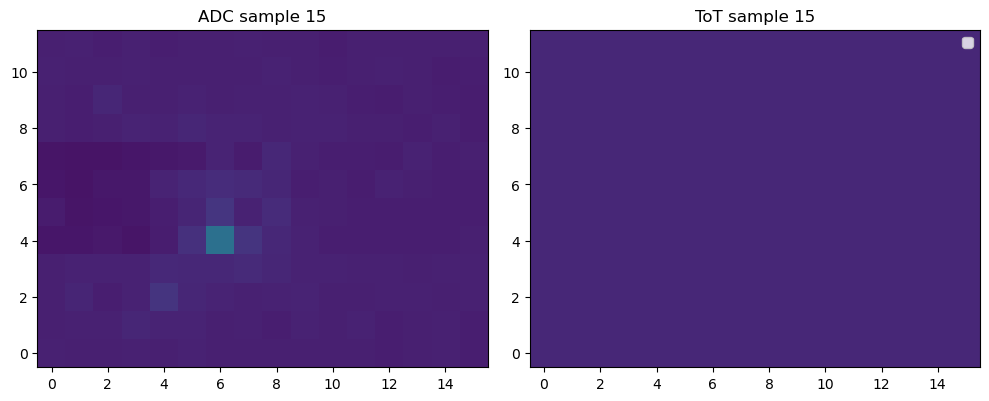

In [169]:
evt = X_train[16]

adc_img = evt[0]
tot_img = evt[1]

sample = 15
vmin = evt[0].min()
vmax = evt[0].max()

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(adc_img[:,:,sample],origin="lower", vmin = vmin, vmax = vmax, label = f't = {sample}')

ax[0].set_title(f"ADC sample {sample}")

ax[1].imshow(tot_img[:,:,sample], origin="lower", vmin = vmin, vmax = vmax, label = f't = {sample}')

ax[1].set_title(f"ToT sample {sample}")

plt.legend()
plt.tight_layout()
plt.show()


from catboost import CatBoostRegressor, Pool
import shap
print(np.shape(input_data))
print(energy_test)


model_full = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MAE',   
    eval_metric='MAE',   
    random_seed=42,
    verbose=100
)

model_full.fit(input_train, energy_train,
    eval_set=(input_test, energy_test),
    early_stopping_rounds=50
)


In [ ]:

del X_train, X_val, y_train, y_val
gc.collect()
mem()
print(MAPPING[:5])
print(DET_ROWS, DET_COLS)

  mem: 9.20 GB
[(1, 79, 0, 0), (1, 83, 0, 1), (1, 89, 0, 2), (1, 91, 0, 3), (1, 99, 0, 4)]
12 16


In [170]:


class FoCal3DNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv3d(
                2,
                16,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.ReLU(),

            nn.Conv3d(
                16,
                32,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool3d((1,2,2)),

            nn.Conv3d(
                32,
                64,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(
                64,
                128,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool3d(1)
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,1)
        )

    def forward(self,x):

        x = self.features(x)

        mu = self.head(x).squeeze(-1)

        return mu
    
# Not used here
def heteroscedastic_loss(
    mu,
    log_sigma,
    target
):

    inv_var = torch.exp(-2*log_sigma)

    loss = (
        0.5 * (target-mu)**2 * inv_var
        + log_sigma
    )

    return loss.mean()

In [ ]:
from tqdm import tqdm

MAE_WEIGHT = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FoCal3DNet().to(device)

n_epochs = 300
train_losses = []
val_losses = []


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=8,
    min_lr=1e-6
)

best_val_mae = np.inf
best_epoch = 0
patience = 24

history = {
    "train_loss": [],
    "val_loss": [],
    "val_mae": [],
    "lr": []
}

# training loop
for epoch in range(n_epochs):

    model.train()

    train_loss = 0.0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{n_epochs}",
        leave=False
    )

    for x, y in pbar:

        x = x.cuda(non_blocking=True)
        y = y.cuda(non_blocking=True)

        optimizer.zero_grad()

        mu = model(x)
        loss = torch.nn.functional.huber_loss(mu, y, delta=1.0)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        train_loss += loss.item() * x.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= len(train_loader.dataset)


# Evaluation stuff

    model.eval()

    val_loss = 0.0

    preds = []
    truths = []

    with torch.no_grad():

        for x, y in val_loader:

            x = x.cuda(non_blocking=True)
            y = y.cuda(non_blocking=True)

            mu = model(x)
            loss = torch.nn.functional.huber_loss(mu, y, delta=1.0)
            val_mae = torch.mean(torch.abs(mu - y))

            val_loss += loss.item() * x.size(0)

            preds.append(
                mu.cpu().numpy()
            )

            truths.append(
                y.cpu().numpy()
            )

    val_loss /= len(val_loader.dataset)

    preds = np.concatenate(preds)
    truths = np.concatenate(truths)

    val_mae = np.mean(
        np.abs(preds - truths)
    )

    scheduler.step(val_mae)

    current_lr = optimizer.param_groups[0]["lr"]


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    history["lr"].append(current_lr)

    print(
            f"Epoch {epoch+1:03d} | "
        f"TrainLoss={train_loss:.4f} | "
        f"ValLoss={val_loss:.4f} | "
        f"ValMAE={val_mae:.4f} | "
        f"LR={current_lr:.2e}"
    )

# early stopping

    min_delta = 1e-4
    if val_mae < best_val_mae - min_delta:

        best_val_mae = val_mae
        best_epoch = epoch
 
        torch.save(
            model.state_dict(),
            "best_model_Huber_image2.pt"
        )

        print(
            f"  ✓ New best model "
            f"(Val MAE={best_val_mae:.4f})"
        )

    elif epoch - best_epoch >= patience:

        print(
            f"\nEarly stopping "
            f"after epoch {epoch+1}"
        )
        break

model.load_state_dict(
    torch.load("best_model_Huber_image2.pt")
)

KeyboardInterrupt: 

In [172]:
model.load_state_dict(
    torch.load("best_model_Huber_image.pt")
)
model.eval()

all_mu = []
all_true = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)

        mu = model(X_batch)

        all_mu.append(mu.cpu().numpy())
        all_true.append(y_batch.numpy())

mu_pred_log = np.concatenate(all_mu)
y_true_log  = np.concatenate(all_true)


model.eval()

preds = []
truths = []

with torch.no_grad():

    for x,y in val_loader:

        x = x.cuda()

        mu = model(x)

        preds.append(
            mu.cpu().numpy()
        )


        truths.append(
            y.numpy()
        )

preds = np.concatenate(preds)
truths = np.concatenate(truths)


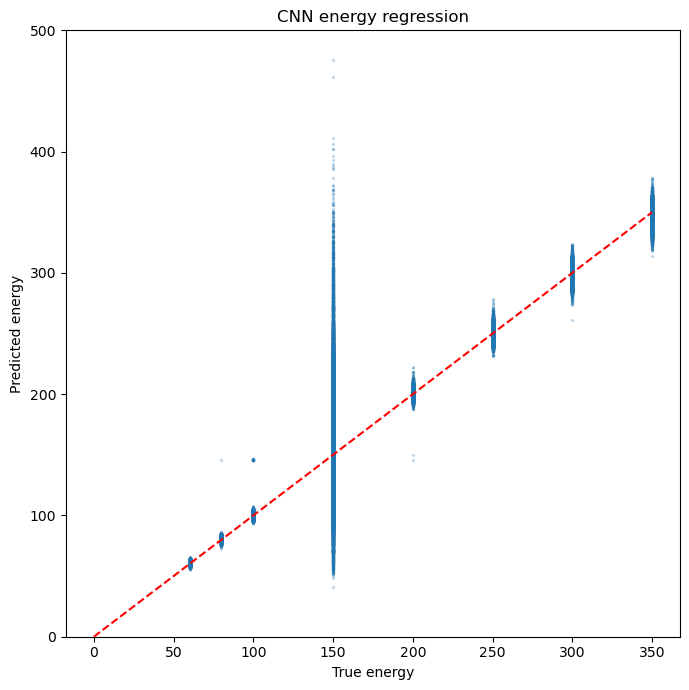

171.46797 51.86489
N events at 150 GeV: 15000


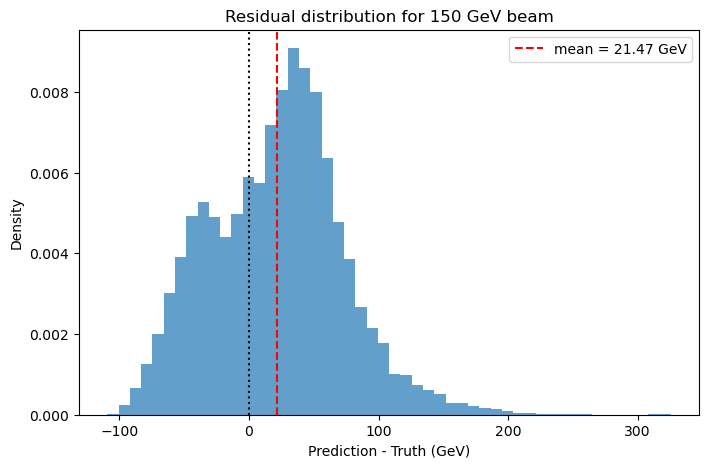

In [173]:
energy_pred = np.expm1(mu_pred_log)
energy_true = np.expm1(y_true_log)
#energy_sigma = np.exp(mu_pred_log) * sigma_log


plt.figure(figsize=(7,7))

plt.scatter(
    energy_true,
    energy_pred,
    s=2,
    alpha=0.2
)

lims = [0, 350
    #min(energy_true.min(), energy_pred.min()),
    #max(energy_true.max(), energy_pred.max())
]

plt.plot(lims, lims, "r--")

plt.xlabel("True energy")
plt.ylabel("Predicted energy")
plt.title("CNN energy regression")
plt.ylim(0,500)

plt.tight_layout()
plt.show()

TARGET_E = 150

mask150 = np.isclose(energy_true, TARGET_E)

pred150 = energy_pred[mask150]
true150 = energy_true[mask150]

residual150 = pred150 - true150

print(np.mean(pred150), np.std(residual150))

print(f"N events at {TARGET_E} GeV: {len(residual150)}")

plt.figure(figsize=(8,5))

plt.hist(
    residual150,
    bins=50,
    density=True,
    alpha=0.7
)

plt.axvline(
    residual150.mean(),
    color="red",
    linestyle="--",
    label=f"mean = {residual150.mean():.2f} GeV"
)

plt.axvline(
    0,
    color="black",
    linestyle=":"
)

plt.xlabel("Prediction - Truth (GeV)")
plt.ylabel("Density")
plt.title("Residual distribution for 150 GeV beam")
plt.legend()

plt.show()

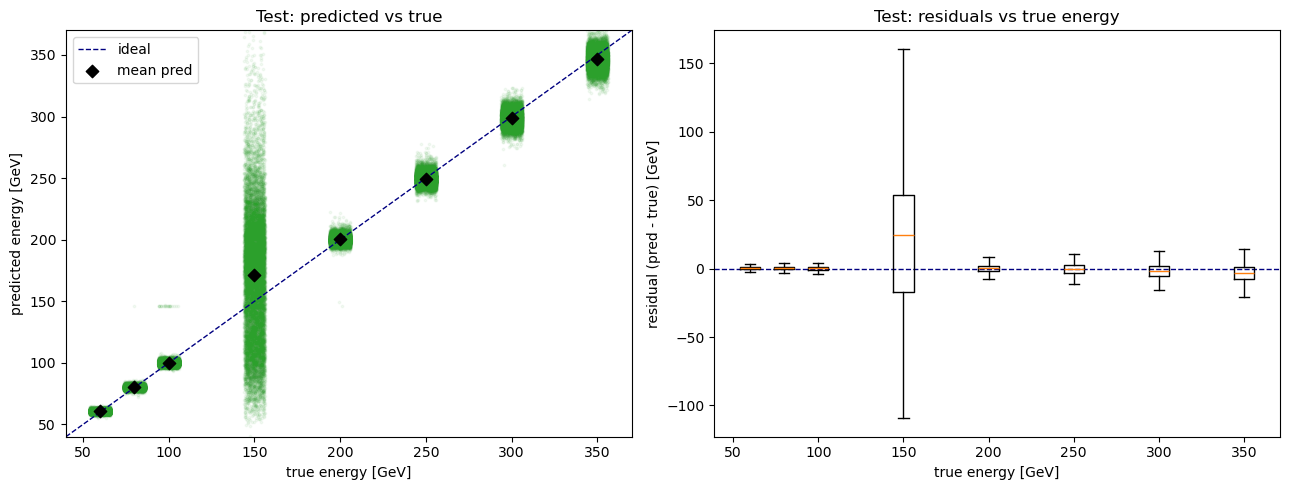

test MAE :    8.17 GeV
test RMSE:   20.25 GeV
test R^2 :  0.9590

per-energy summary:
   E[GeV]      n  mean pred     bias     std  sigma/E
       59  15000       60.7     +0.7     1.1    0.018
       80  15000       80.4     +0.4     1.4    0.018
       99  15000      100.2     +0.2     2.5    0.025
      149  15000      171.5    +21.5    51.9    0.346
      199  15000      200.3     +0.3     3.1    0.016
      250  15000      249.6     -0.4     4.4    0.017
      300  15000      298.6     -1.4     5.6    0.019
      350  15000      346.7     -3.3     6.9    0.020


In [174]:
from sklearn.metrics import r2_score

mae  = np.mean(np.abs(energy_pred - energy_true))
rmse = np.sqrt(np.mean((energy_pred - energy_true) ** 2))
r2   = r2_score(energy_true, energy_pred)
energies_sorted = np.array(sorted(np.unique(energy_true)))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

lo, hi = energy_true.min() - 20, energy_true.max() + 20
ax[0].plot([lo, hi], [lo, hi], "--", color="navy", lw=1, label="ideal")
ax[0].scatter(energy_true + np.random.uniform(-6, 6, len(energy_true)), energy_pred,
              s=3, alpha=0.05, color="#2ca02c")
ax[0].scatter(energies_sorted, [energy_pred[energy_true == E].mean() for E in energies_sorted],
              color="black", marker="D", s=40, zorder=5, label="mean pred")
ax[0].set_xlabel("true energy [GeV]"); ax[0].set_ylabel("predicted energy [GeV]")
ax[0].set_title("Test: predicted vs true"); ax[0].legend(loc="upper left")
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)

ax[1].axhline(0, color="navy", ls="--", lw=1)
parts = [(energy_pred - energy_true)[energy_true == E] for E in energies_sorted]
ax[1].boxplot(parts, positions=energies_sorted, widths=12, showfliers=False,
              manage_ticks=False)
ax[1].set_xlabel("true energy [GeV]"); ax[1].set_ylabel("residual (pred - true) [GeV]")
ax[1].set_title("Test: residuals vs true energy")
plt.tight_layout(); plt.show()

print(f"test MAE :  {mae:6.2f} GeV")
print(f"test RMSE:  {rmse:6.2f} GeV")
print(f"test R^2 :  {r2:6.4f}")
print("\nper-energy summary:")
print(f"  {'E[GeV]':>7} {'n':>6} {'mean pred':>10} {'bias':>8} {'std':>7} {'sigma/E':>8}")
for E in energies_sorted:
    m = energy_true == E
    mp, sd = energy_pred[m].mean(), energy_pred[m].std()
    print(f"  {int(E):>7} {m.sum():>6} {mp:>10.1f} {mp - E:>+8.1f} {sd:>7.1f} {sd / E:>8.3f}")


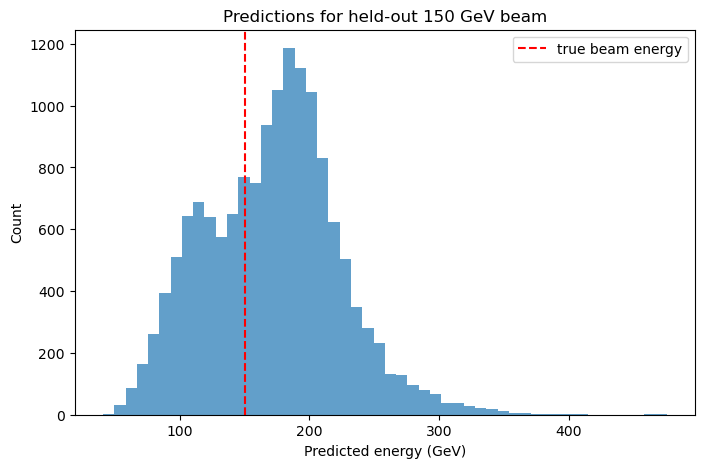

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    pred150,
    bins=50,
    alpha=0.7
)

plt.axvline(
    150,
    color="red",
    linestyle="--",
    label="true beam energy"
)

plt.xlabel("Predicted energy (GeV)")
plt.ylabel("Count")
plt.title("Predictions for held-out 150 GeV beam")
plt.legend()

plt.show()

In [10]:
relative_mae = np.mean(
    np.abs(energy_pred - energy_true) / energy_true
)

print(f"Relative MAE: {100*relative_mae:.2f}%")

mask2 = energy_true > 0

mae = np.mean(
    np.abs(energy_pred - energy_true)
)

print(f"MAE: {mae:.2f}")


Relative MAE: 5.07%
MAE: 8.17


In [11]:
pred_energy = np.expm1(preds)
true_energy = np.expm1(truths)

for e in np.unique(energy_true):
    mask = energy_true == e
    mae = np.mean(
        np.abs(pred_energy[mask] - true_energy[mask])
    )
    print(f"{int(e):3d} GeV : MAE = {mae:.3f} GeV")

 59 GeV : MAE = 1.063 GeV
 80 GeV : MAE = 1.103 GeV
 99 GeV : MAE = 1.348 GeV
149 GeV : MAE = 45.450 GeV
199 GeV : MAE = 2.390 GeV
250 GeV : MAE = 3.399 GeV
300 GeV : MAE = 4.537 GeV
350 GeV : MAE = 6.035 GeV


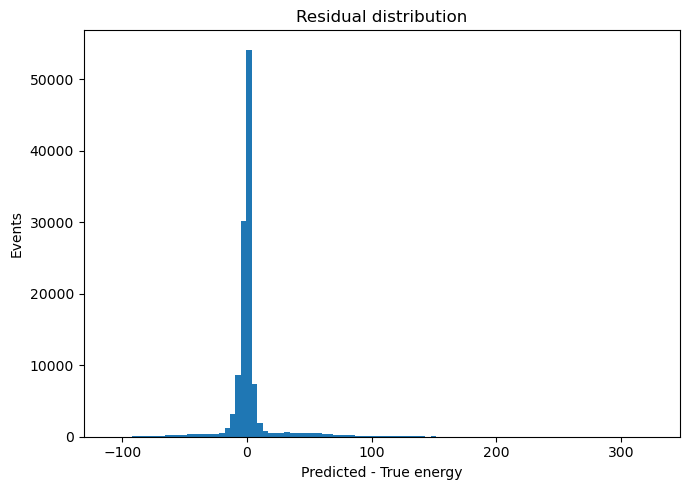

20.129868
8.165599


In [12]:
residual = energy_pred - energy_true

plt.figure(figsize=(7,5))

plt.hist(
    residual,
    bins=100
)

plt.xlabel("Predicted - True energy")
plt.ylabel("Events")
plt.title("Residual distribution")

plt.tight_layout()
plt.show()

print(np.std(residual))
print(np.mean(np.abs(residual)))

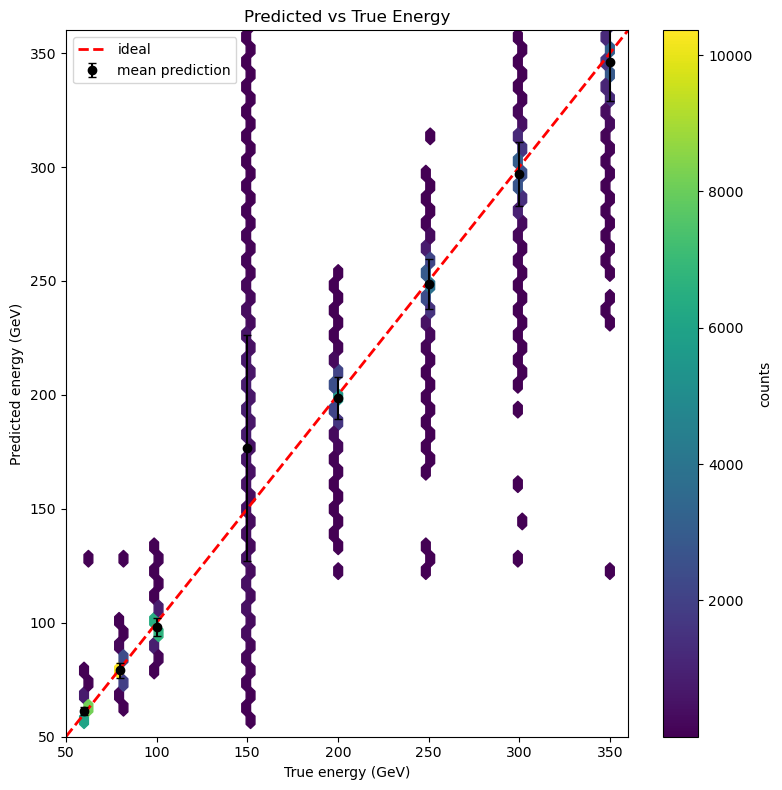

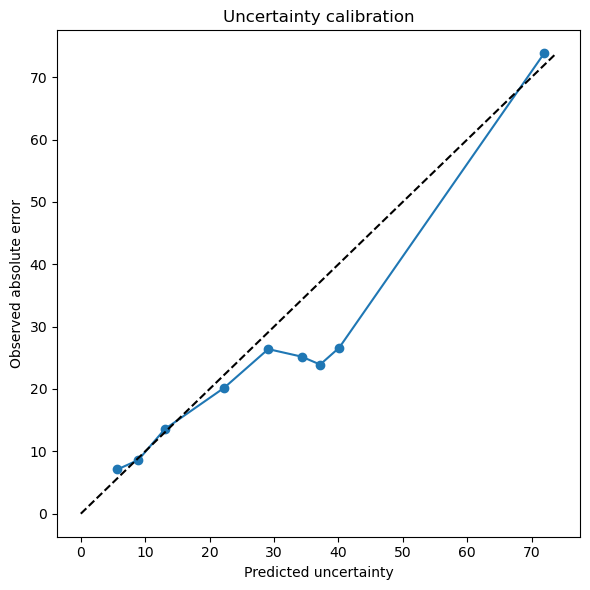

In [ ]:
abs_error = np.abs(
    energy_pred - energy_true
)

bins = np.quantile(energy_sigma, np.linspace(0, 1, 10))
#print(bins)
#bins = np.linspace(0, 100, 10)
mean_sigma = []
mean_error = []

for i in range(len(bins)-1):

    mask = (
        (energy_sigma >= bins[i]) &
        (energy_sigma < bins[i+1])
    )

    mean_sigma.append(
        energy_sigma[mask].mean()
    )

    mean_error.append(
        abs_error[mask].mean())



plt.figure(figsize=(6,6))

plt.plot(
    mean_sigma,
    mean_error,
    "o-"
)

mx = max(
    max(mean_sigma),
    max(mean_error)
)

plt.plot([0,mx],[0,mx],"k--")

plt.xlabel("Predicted uncertainty")
plt.ylabel("Observed absolute error")

plt.title("Uncertainty calibration")

plt.tight_layout()
plt.show()